<b>Aktywność 6</b><br>
Niezbędne biblioteki: geopandas, pandas, pathlib, pyproj, shapely

<b>Ćwiczenie 1.</b> Na podstawie wartości ze zmiennych longitudes i latitudes utwórz listę krotek zawierających współrzędne o nazwie coordinate_pairs.

In [186]:
import shapely.plotting

longitudes = [29.99671173095703,  31.58196258544922,  27.738052368164062, 26.50013542175293,
              26.652359008789062, 25.921663284301758, 22.90027618408203,  23.257217407226562,
              23.335693359375,    22.87444305419922,  23.08465003967285,  22.565473556518555,
              21.452774047851562, 21.66388702392578,  21.065969467163086, 21.67659568786621,
              21.496871948242188, 22.339998245239258, 22.288192749023438, 24.539581298828125,
              25.444232940673828, 25.303749084472656, 24.669166564941406, 24.689163208007812,
              24.174999237060547, 23.68471908569336,  24.000761032104492, 23.57332992553711,
              23.76513671875,     23.430830001831055, 23.6597900390625,   20.580928802490234,
              21.320831298828125, 22.398330688476562, 23.97638702392578,  24.934917449951172,
              25.7611083984375,   25.95930290222168,  26.476804733276367, 27.91069221496582,
              29.1027774810791,   29.29846954345703,  28.4355525970459,   28.817358016967773,
              28.459857940673828, 30.028610229492188, 29.075136184692383, 30.13492774963379,
              29.818885803222656, 29.640830993652344, 30.57735824584961,  29.99671173095703]
latitudes  = [63.748023986816406, 62.90789794921875,  60.511383056640625, 60.44499588012695,
              60.646385192871094, 60.243743896484375, 59.806800842285156, 59.91944122314453,
              60.02395248413086,  60.14555358886719,  60.3452033996582,   60.211936950683594,
              60.56249237060547,  61.54027557373047,  62.59798049926758,  63.02013397216797,
              63.20353698730469,  63.27652359008789,  63.525691986083984, 64.79915618896484,
              64.9533920288086,   65.51513671875,     65.65470886230469,  65.89610290527344,
              65.79151916503906,  66.26332092285156,  66.80228424072266,  67.1570053100586,
              67.4168701171875,   67.47978210449219,  67.94589233398438,  69.060302734375,
              69.32611083984375,  68.71110534667969,  68.83248901367188,  68.580810546875,
              68.98916625976562,  69.68568420410156,  69.9363784790039,   70.08860778808594,
              69.70597076416016,  69.48533630371094,  68.90263366699219,  68.84700012207031,
              68.53485107421875,  67.69471740722656,  66.90360260009766,  65.70887756347656,
              65.6533203125,      64.92096710205078,  64.22373962402344,  63.748023986816406]

In [187]:
### your code ###
coordinate_pairs = []
for i in range(len(longitudes)) :
    coordinate_pairs.append((longitudes[i], latitudes[i]))

Zweryfikuj poprawność kodu.

In [188]:
print(coordinate_pairs[0])

(29.99671173095703, 63.748023986816406)


<b>Ćwiczenie 2.</b> Utwórz obiekt typu Polygon o nazwie polygon wykorzystując zmienną coordinate_pairs.

In [189]:
from shapely.geometry import Polygon

### your code ###
polygon = Polygon(coordinate_pairs)

Zweryfikuj poprawność kodu.

In [190]:
print(polygon.geom_type)

Polygon


<b>Ćwiczenie 3.</b> Utwórz obiekt typu GeoDataFrame o nazwie geo i układzie współrzędnych EPSG:4326 zawierający kolumnę o nazwie geometry. Wczytaj tam wielokąt o nazwie polygon.

In [191]:
import geopandas as gpd

### your code ###
dicto = {"geometry" : [polygon]}
geo = gpd.GeoDataFrame(dicto, crs="EPSG:4326")

Zweryfikuj poprawność kodu.

In [192]:
geo.head()

,geometry
0,"POLYGON ((29.99671 63.74802, 31.58196 62.9079,..."


<b>Ćwiczenie 4.</b> Zwizualizuj wielokąt.

(<matplotlib.patches.PathPatch at 0x280ae90bad0>,
 <matplotlib.lines.Line2D at 0x280ad37ff20>)

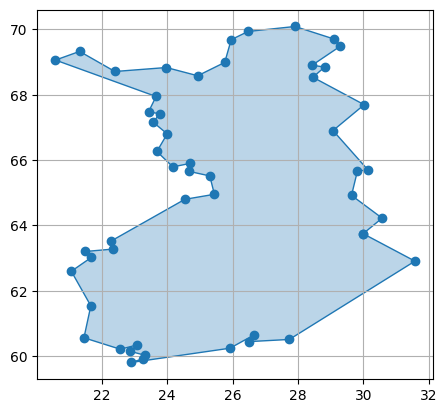

In [193]:
### your code ###
import shapely.plotting as shlpt
shlpt.plot_polygon(polygon)

<b>Ćwiczenie 5.</b> Zapisz plik w formacie GeoPackage pod nazwą ``mysterious-polygon.gpkg``.

In [194]:
### your code ###
output_file = "mysterious-polygon.gpkg"
geo.to_file(output_file, driver='GPKG')

In [195]:
import pathlib

assert (pathlib.Path().resolve() / "mysterious-polygon.gpkg").exists(), "Plik nie został zapisany!"

<b>Ćwiczenie 6.</b> Wczytaj dane z pliku ``some_posts.csv`` do obiektu typu DataFrame o nazwie data.

In [196]:
import pandas as pd

### your code ###
data = pd.read_csv("some_posts.csv", sep=',')

Zweryfikuj poprawność kodu.

In [197]:
print(f"Number of rows: {len(data)}")

Number of rows: 81379


<b>Ćwiczenie 7.</b> Do zmiennej data dodaj kolumnę o nazwie geometry. Wstaw do niej obiekty typu Point na podstawie kolumn lon i lat.

In [198]:
from shapely.geometry import Point

### your code ###

points = []
for i in range(len(data)):
    points.append(Point(data['lon'][i], data['lat'][i]))
data['geometry'] = pd.Series(points)


Zweryfikuj poprawność kodu.

In [199]:
data['geometry'].head()

0    POINT (31.484633302 -24.980792492)
1    POINT (31.508905612 -25.499224667)
2    POINT (30.930866066 -24.342578456)
3     POINT (31.519718439 -24.85461393)
4    POINT (31.520835558 -24.921068894)
Name: geometry, dtype: object

<b>Ćwiczenie 8.</b> Przekonwertuj obiekt typu DataFrame na obiekt typu GeoDataFrame. Ustaw przestrzenny układ odniesienia na EPSG:4326.

In [200]:
### your code ###
#dicto = {"geometry" : [data]}
data = gpd.GeoDataFrame(data, crs="EPSG:4326", geometry='geometry')

Zweryfikuj poprawność kodu.

In [201]:
data

,lat,lon,timestamp,userid,geometry
0,-24.980792,31.484633,2015-07-07 03:02,66487960,POINT (31.48463 -24.98079)
1,-25.499225,31.508906,2015-07-07 03:18,65281761,POINT (31.50891 -25.49922)
2,-24.342578,30.930866,2015-03-07 03:38,90916112,POINT (30.93087 -24.34258)
3,-24.854614,31.519718,2015-10-07 05:04,37959089,POINT (31.51972 -24.85461)
4,-24.921069,31.520836,2015-10-07 05:19,27793716,POINT (31.52084 -24.92107)
...,...,...,...,...,...
81374,-24.799541,31.354469,2015-09-05 02:23,90744213,POINT (31.35447 -24.79954)
81375,-25.467992,30.956033,2015-02-05 02:40,71109799,POINT (30.95603 -25.46799)
81376,-25.332223,30.997409,2015-08-05 02:40,54796261,POINT (30.99741 -25.33222)
81377,-25.508851,31.005536,2015-08-05 02:43,78762204,POINT (31.00554 -25.50885)


In [202]:
print(data.crs)

EPSG:4326


<b>Ćwiczenie 9.</b> Zapisz plik w formacie Shapefile pod nazwą ``kruger_points.shp``.

In [203]:
### your code ###
output_file = "kruger_points.shp"
data.to_file(output_file, driver='ESRI Shapefile')

Zweryfikuj poprawność kodu.

In [204]:
import pathlib

assert (pathlib.Path().resolve() / "kruger_points.shp").exists(), "Plik nie został zapisany!"

<b>Ćwiczenie 10.</b> Zwizualizuj punkty.

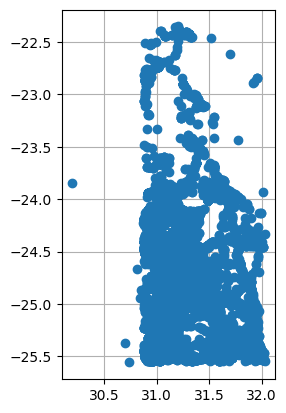

In [205]:
### your code ###
shlpt.plot_points(data['geometry'])

<b>Ćwiczenie 11.</b> Wczytaj dane z pliku ``kruger_points.shp`` do obiektu typu GeoDataFrame o nazwie kruger_points.

In [206]:
### your code ###
kruger_points = gpd.read_file("kruger_points.shp")

Zweryfikuj poprawność kodu.

In [207]:
kruger_points.head()

,lat,lon,timestamp,userid,geometry
0,-24.980792,31.484633,2015-07-07 03:02,66487960,POINT (31.48463 -24.98079)
1,-25.499225,31.508906,2015-07-07 03:18,65281761,POINT (31.50891 -25.49922)
2,-24.342578,30.930866,2015-03-07 03:38,90916112,POINT (30.93087 -24.34258)
3,-24.854614,31.519718,2015-10-07 05:04,37959089,POINT (31.51972 -24.85461)
4,-24.921069,31.520836,2015-10-07 05:19,27793716,POINT (31.52084 -24.92107)


<b>Ćwiczenie 12.</b> Przeprowadź projekcję danych na układ odniesienia EPSG:32735, w którym domyślną jednostką są metry.

In [208]:
### your code ###
kruger_points = kruger_points.to_crs("EPSG:32735")

Zweryfikuj poprawność kodu.

In [209]:
import pyproj

assert kruger_points.crs == pyproj.CRS("EPSG:32735"), "Błędnie wykonana projekcja!"

<b>Ćwiczenie 13.</b> Pogrupuj dane po kolumnie userid w zmiennej o nazwie grouped_by_users.

In [210]:
### your code ###
grouped_by_users = kruger_points.groupby('userid')

Zweryfikuj poprawność kodu.

In [211]:
assert len(grouped_by_users.groups) == kruger_points["userid"].nunique(), "Błędna liczba grup!"

<b>Ćwiczenie 14.</b> Dla każdego użytkownika posortuj rezultaty po kolumnie timestamp i utwórz obiekt typu LineString na podstawie jego punktów. Pamiętaj, aby pominąć użytkowników, którzy posiadają mniej niż dwa punkty. Rezultaty (zawierające kolumny userid oraz geometry) zapisz w obiekcie typu GeoDataFrame o nazwie movements. Pamiętaj o weryfikacji układu odniesienia.

In [212]:
from shapely.geometry import LineString

### your code ###
movements = []

for user_id, group in grouped_by_users:
    
    group = group.sort_values(by = 'timestamp')
    
    if len(group) >= 2:
        movements.append({'userid': user_id, 'geometry': LineString(group['geometry'])})
        
movements = gpd.GeoDataFrame(movements, crs="EPSG:4326")


Zweryfikuj poprawność kodu.

In [213]:
movements

,userid,geometry
0,16301,"LINESTRING (942231.63037 7254606.86776, 938934..."
1,45136,"LINESTRING (905394.50015 7193375.14849, 905394..."
2,50136,"LINESTRING (944551.60685 7253384.18284, 963788..."
3,88775,"LINESTRING (902800.81655 7192546.97505, 902800..."
4,88918,"LINESTRING (959332.96075 7219877.71476, 963788..."
...,...,...
9021,99921781,"LINESTRING (902885.19 7196931.09644, 904027.71..."
9022,99936874,"LINESTRING (963782.21059 7228000.07884, 963754..."
9023,99964140,"LINESTRING (938876.65339 7305143.36937, 938876..."
9024,99986933,"LINESTRING (935937.02857 7305973.53562, 936598..."


<b>Ćwiczenie 15.</b> Dodaj kolumnę o nazwie distance, która będzie przechowywać długość linii.

In [214]:
### your code ###
movements['distance'] = movements['geometry'].apply(lambda x: x.length)

Zweryfikuj poprawność kodu.

In [215]:
movements.head()

,userid,geometry,distance
0,16301,"LINESTRING (942231.63037 7254606.86776, 938934...",328455.115430
1,45136,"LINESTRING (905394.50015 7193375.14849, 905394...",0.000000
2,50136,"LINESTRING (944551.60685 7253384.18284, 963788...",159189.081019
3,88775,"LINESTRING (902800.81655 7192546.97505, 902800...",0.080245
4,88918,"LINESTRING (959332.96075 7219877.71476, 963788...",9277.252211


<b>Ćwiczenie 16.</b> Odpowiedz na poniższe pytania i zapisz ich rezultaty w podanych zmiennych:<br/>
1. Jaki był najkrótszy dystans pokonany przez użytkownika (shortest_distance)?<br/>
2. Jaki był średni dystans pokonany przez użytkownika (mean_distance)?<br/>
3. Jaki był najdłuższy dystans pokonany przez użytkownika (longest_distance)?<br/>

In [216]:
### your code ###
shortest_distance = movements['distance'].min()
print(shortest_distance)

average_distance = movements['distance'].mean()
print(average_distance)

longest_distance = movements['distance'].max()
print(longest_distance)

0.0
107133.51202944393
6970668.816343964


<b>Ćwiczenie 17.</b> Zapisz plik w formacie Shapefile pod nazwą ``movements.shp``.

In [219]:
### your code ###
movements.to_file('movements.shp')

Zweryfikuj poprawność kodu.

In [221]:
assert (pathlib.Path().resolve() / "movements.shp").exists(), "Plik nie został zapisany!"